In [1]:

import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('TensorFlow Version: ', tf.__version__)
print('Keras Version: ', keras.__version__)

/kaggle/input/datasets/virgintarek/churn-modelling-csv/Churn_Modelling.csv
TensorFlow Version:  2.20.0
Keras Version:  3.13.2


In [3]:
df = pd.read_csv('/kaggle/input/datasets/virgintarek/churn-modelling-csv/Churn_Modelling.csv')

X = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df['Exited'].values

X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)


X_train shape:  (8000, 11)
X_test shape:  (2000, 11)
y_train shape:  (8000,)


In [4]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],), name='hidden_1'))

model.add(Dense(128, activation='relu', name='hidden_2'))
model.add(Dense(64, activation='relu', name='hidden_3'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid', name='output'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-16 23:01:42.830746: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,289 (173.00 KB)

 Trainable params: 44,289 (173.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:

hidden_1 = model.layers[0]
h1_weights, h1_bias = hidden_1.get_weights()
print("\nFirst layer weights shape:", h1_weights.shape)
print("First layer bias shape:", h1_bias.shape)


model.compile(
    loss='binary_crossentropy', # استبدال sparse_categorical_crossentropy بـ binary_crossentropy
    optimizer='adam',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)



First layer weights shape: (11, 256)
First layer bias shape: (256,)


In [10]:

from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_cb = ModelCheckpoint("churn_model.h5", save_best_only=True)
early_stopping_cb = EarlyStopping(patience=10, restore_best_weights=True)
lr_cb = ReduceLROnPlateau(patience=5, factor=0.2)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    callbacks=[checkpoint_cb, lr_cb]
)

Epoch 1/15
213/225 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8726 - loss: 0.3254 - precision: 0.8053 - recall: 0.4999

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8668 - loss: 0.3323 - precision: 0.7880 - recall: 0.4804 - val_accuracy: 0.8687 - val_loss: 0.3073 - val_precision: 0.7765 - val_recall: 0.4342 - learning_rate: 2.5600e-09
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8654 - loss: 0.3322 - precision: 0.7869 - recall: 0.4723 - val_accuracy: 0.8687 - val_loss: 0.3073 - val_precision: 0.7765 - val_recall: 0.4342 - learning_rate: 2.5600e-09
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8656 - loss: 0.3324 - precision: 0.7859 - recall: 0.4743 - val_accuracy: 0.8687 - val_loss: 0.3073 - val_precision: 0.7765 - val_recall: 0.4342 - learning_rate: 2.5600e-09
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8654 - loss: 0.3338 - precision: 0.7889 - recall: 0.4702 - val_accuracy: 0.8687 - val_loss: 0.3073 - val_precision: 0.7765 - val_recall: 0.4342 - learning_rate: 2.5600e-09
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accur

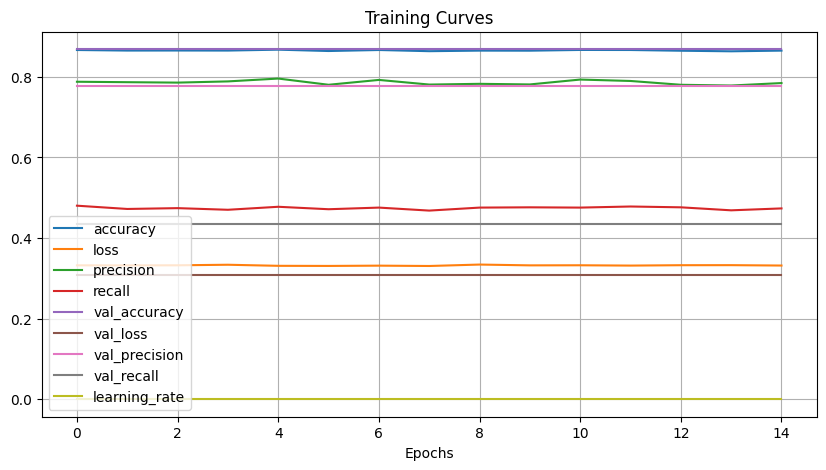

In [11]:

learning_data = pd.DataFrame(history.history)
learning_data.plot(figsize=(10, 5))
plt.grid(True)
plt.title("Training Curves")
plt.xlabel("Epochs")
plt.show()


In [12]:
results = model.evaluate(X_test, y_test)
print(f"\nTest Loss & Metrics: {results}")

X_new = X_test[5].reshape(1, -1)
y_pred_prob = model.predict(X_new)
y_pred_class = (y_pred_prob > 0.5).astype("int32")

print('Actual Class:', y_test[5])
print('Predicted Probability:', y_pred_prob[0][0])
print('Predicted Class:', y_pred_class[0][0])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8675 - loss: 0.3353 - precision: 0.8060 - recall: 0.4595 

Test Loss & Metrics: [0.3353305160999298, 0.8675000071525574, 0.806034505367279, 0.45945945382118225]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Actual Class: 0
Predicted Probability: 0.18647465
Predicted Class: 0
